In [3]:
from google.colab import drive
import os

if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')
else:
    print("✅ Drive already mounted")

✅ Drive already mounted


In [4]:
os.system("pip install monai nibabel torch torchvision scikit-learn tqdm -q")
print("✅ Dependencies installed!")

✅ Dependencies installed!


In [5]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.model_selection import KFold
import nibabel as nib
from monai.losses import DiceLoss as MONAIDiceLoss, FocalLoss
from tqdm import tqdm
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.09 GB


In [6]:
RAW_ROOT   = "/content/drive/MyDrive/MIA/7960856/ISLES-2022"
MASK_ROOT  = "/content/drive/MyDrive/MIA/7960856/ISLES-2022/derivatives"
OUTPUT_DIR = "/content/drive/MyDrive/MIA/ISLES_RESULTS_MULTIINPUT"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("✅ Paths set")

✅ Paths set


In [7]:
# ── Helpers ──
def load_and_resize(path, spatial_size=(128, 128, 128), is_mask=False):
    vol = nib.load(path).get_fdata()
    vol = torch.tensor(np.expand_dims(vol, 0), dtype=torch.float32)
    mode = "nearest" if is_mask else "trilinear"
    kwargs = {} if is_mask else {"align_corners": False}
    return F.interpolate(vol.unsqueeze(0), size=spatial_size,
                         mode=mode, **kwargs).squeeze(0)

def zscore_norm(vol):
    return (vol - vol.mean()) / (vol.std() + 1e-8)

def augment_data(dwi, adc, flair, mask):
    if np.random.rand() > 0.5:
        axis = np.random.randint(1, 4)
        dwi   = torch.flip(dwi,   [axis])
        adc   = torch.flip(adc,   [axis])
        flair = torch.flip(flair, [axis])
        mask  = torch.flip(mask,  [axis])
    if np.random.rand() > 0.5:
        dwi   = torch.clamp(dwi   + torch.randn_like(dwi)   * 0.05, 0, 1)
        adc   = torch.clamp(adc   + torch.randn_like(adc)   * 0.05, 0, 1)
        flair = torch.clamp(flair + torch.randn_like(flair) * 0.05, 0, 1)
    return dwi, adc, flair, mask

# ── Dataset ──
class ISLESMultiInputDataset(Dataset):
    def __init__(self, case_ids, raw_root, mask_root, augment=False):
        self.case_ids  = case_ids
        self.raw_root  = raw_root
        self.mask_root = mask_root
        self.augment   = augment

    def __len__(self):
        return len(self.case_ids)

    def __getitem__(self, idx):
        case_id  = self.case_ids[idx]
        dwi_dir  = os.path.join(self.raw_root, case_id, "ses-0001", "dwi")
        anat_dir = os.path.join(self.raw_root, case_id, "ses-0001", "anat")

        dwi   = zscore_norm(load_and_resize(
                    os.path.join(dwi_dir,  f"{case_id}_ses-0001_dwi.nii.gz")))
        adc   = zscore_norm(load_and_resize(
                    os.path.join(dwi_dir,  f"{case_id}_ses-0001_adc.nii.gz")))
        flair = zscore_norm(load_and_resize(
                    os.path.join(anat_dir, f"{case_id}_ses-0001_FLAIR.nii.gz")))
        mask  = load_and_resize(
                    os.path.join(self.mask_root, case_id, "ses-0001",
                                 f"{case_id}_ses-0001_msk.nii.gz"),
                    is_mask=True)

        if self.augment:
            dwi, adc, flair, mask = augment_data(dwi, adc, flair, mask)

        img = torch.cat([dwi, adc, flair], dim=0)
        return img, mask, case_id

# ── Model ──
class ConvBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.block(x)

class Encoder3D(nn.Module):
    def __init__(self, channels=(16, 32, 64, 128)):
        super().__init__()
        self.enc1 = ConvBlock3D(1,           channels[0])
        self.enc2 = ConvBlock3D(channels[0], channels[1])
        self.enc3 = ConvBlock3D(channels[1], channels[2])
        self.enc4 = ConvBlock3D(channels[2], channels[3])
        self.pool = nn.MaxPool3d(2)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2))
        s4 = self.enc4(self.pool(s3))
        return s4, [s1, s2, s3]

class MultiInputUNet3D(nn.Module):
    def __init__(self):
        super().__init__()
        ch = (16, 32, 64, 128)
        self.enc_dwi   = Encoder3D(ch)
        self.enc_adc   = Encoder3D(ch)
        self.enc_flair = Encoder3D(ch)
        self.bottleneck = ConvBlock3D(ch[3]*3, 256)
        self.up3  = nn.ConvTranspose3d(256, 128, 2, stride=2)
        self.dec3 = ConvBlock3D(128 + ch[2]*3, 128)
        self.up2  = nn.ConvTranspose3d(128, 64, 2, stride=2)
        self.dec2 = ConvBlock3D(64  + ch[1]*3,  64)
        self.up1  = nn.ConvTranspose3d(64,  32, 2, stride=2)
        self.dec1 = ConvBlock3D(32  + ch[0]*3,  32)
        self.out_conv = nn.Conv3d(32, 1, kernel_size=1)

    def forward(self, x):
        dwi, adc, flair = x[:, 0:1], x[:, 1:2], x[:, 2:3]
        b_dwi,   [s1d, s2d, s3d] = self.enc_dwi(dwi)
        b_adc,   [s1a, s2a, s3a] = self.enc_adc(adc)
        b_flair, [s1f, s2f, s3f] = self.enc_flair(flair)
        x = self.bottleneck(torch.cat([b_dwi, b_adc, b_flair], dim=1))
        x = self.dec3(torch.cat([self.up3(x), s3d, s3a, s3f], dim=1))
        x = self.dec2(torch.cat([self.up2(x), s2d, s2a, s2f], dim=1))
        x = self.dec1(torch.cat([self.up1(x), s1d, s1a, s1f], dim=1))
        return self.out_conv(x)

# ── Metrics ──
def compute_dice(pred, target, threshold=0.5):
    pred_bin = (torch.sigmoid(pred) > threshold).float()
    return 2.0*(pred_bin*target).sum().item() / \
           (pred_bin.sum().item() + target.sum().item() + 1e-5)

def compute_f1(pred, target, threshold=0.5):
    pred_bin = (torch.sigmoid(pred) > threshold).float()
    tp = (pred_bin * target).sum().item()
    fp = (pred_bin * (1 - target)).sum().item()
    fn = ((1 - pred_bin) * target).sum().item()
    p  = tp / (tp + fp + 1e-5)
    r  = tp / (tp + fn + 1e-5)
    return 2*p*r / (p + r + 1e-5)

# ── Train / Val functions ──
def train_epoch(model, loader, optimizer, dice_loss, focal_loss, device):
    model.train()
    total_loss, total_dice = 0, 0
    for imgs, masks, _ in tqdm(loader, desc="Training"):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = 0.7*dice_loss(preds, masks) + 0.3*focal_loss(preds, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        total_dice += compute_dice(preds, masks)
    return total_loss/len(loader), total_dice/len(loader)

@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    total_dice, total_f1 = 0, 0
    for imgs, masks, _ in tqdm(loader, desc="Validating"):
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        total_dice += compute_dice(preds, masks)
        total_f1   += compute_f1(preds, masks)
    return total_dice/len(loader), total_f1/len(loader)

# ── K-Fold Splits ──
all_cases = np.array(sorted([
    f for f in os.listdir(RAW_ROOT)
    if f.startswith("sub-strokecase")
]))
kf     = KFold(n_splits=5, shuffle=True, random_state=42)
splits = list(kf.split(all_cases))

print(f"Total subjects: {len(all_cases)}")
print("✅ Everything ready — run each fold cell independently")

Total subjects: 250
✅ Everything ready — run each fold cell independently


In [8]:
case = "sub-strokecase0001"
dwi_path   = f"{RAW_ROOT}/{case}/ses-0001/dwi/{case}_ses-0001_dwi.nii.gz"
adc_path   = f"{RAW_ROOT}/{case}/ses-0001/dwi/{case}_ses-0001_adc.nii.gz"
flair_path = f"{RAW_ROOT}/{case}/ses-0001/anat/{case}_ses-0001_FLAIR.nii.gz"
mask_path  = f"{MASK_ROOT}/{case}/ses-0001/{case}_ses-0001_msk.nii.gz"

print("── RAW SHAPES ──")
print("DWI:  ", nib.load(dwi_path).shape)
print("ADC:  ", nib.load(adc_path).shape)
print("FLAIR:", nib.load(flair_path).shape)
print("MASK: ", nib.load(mask_path).shape)

print("\n── AFTER RESIZE TO (128,128,128) ──")
print("DWI:  ", load_and_resize(dwi_path).shape)
print("ADC:  ", load_and_resize(adc_path).shape)
print("FLAIR:", load_and_resize(flair_path).shape)
print("MASK: ", load_and_resize(mask_path, is_mask=True).shape)

── RAW SHAPES ──
DWI:   (112, 112, 73)
ADC:   (112, 112, 73)
FLAIR: (281, 352, 352)
MASK:  (112, 112, 73)

── AFTER RESIZE TO (128,128,128) ──
DWI:   torch.Size([1, 128, 128, 128])
ADC:   torch.Size([1, 128, 128, 128])
FLAIR: torch.Size([1, 128, 128, 128])
MASK:  torch.Size([1, 128, 128, 128])


In [ ]:
FOLD = 1
train_idx, val_idx     = splits[FOLD-1]
train_cases, val_cases = all_cases[train_idx], all_cases[val_idx]
print(f"Fold {FOLD} | Train: {len(train_cases)} | Val: {len(val_cases)}")

train_loader = DataLoader(
    ISLESMultiInputDataset(train_cases, RAW_ROOT, MASK_ROOT, augment=True),
    batch_size=2, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(
    ISLESMultiInputDataset(val_cases, RAW_ROOT, MASK_ROOT),
    batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

model      = MultiInputUNet3D().to(device)
optimizer  = Adam(model.parameters(), lr=5e-4)
scheduler  = CosineAnnealingLR(optimizer, T_max=30)
dice_loss  = MONAIDiceLoss(to_onehot_y=False, sigmoid=True)
focal_loss = FocalLoss(alpha=0.5, gamma=2.0)

best_dice, patience_counter, PATIENCE = 0, 0, 8
history = []

for epoch in range(30):
    train_loss, train_dice = train_epoch(model, train_loader, optimizer,
                                         dice_loss, focal_loss, device)
    val_dice, val_f1       = validate(model, val_loader, device)
    scheduler.step()
    history.append({"epoch": epoch+1, "train_loss": train_loss,
                    "train_dice": train_dice, "val_dice": val_dice, "val_f1": val_f1})
    print(f"Ep {epoch+1:3d} | Loss: {train_loss:.4f} | "
          f"Train: {train_dice:.4f} | Val: {val_dice:.4f} | F1: {val_f1:.4f}")

    if val_dice > best_dice:
        best_dice, patience_counter = val_dice, 0
        torch.save(model.state_dict(),
                   os.path.join(OUTPUT_DIR, "fold1_best.pt"))
        print(f"  ✅ Fold 1 model saved (Dice: {best_dice:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  ⏹ Early stop at epoch {epoch+1}")
            break

# Save fold 1 results
fold1_result = {"best_dice": float(best_dice), "last_f1": float(val_f1), "history": history}
with open(os.path.join(OUTPUT_DIR, "fold1_results.json"), "w") as f:
    json.dump(fold1_result, f, indent=2)
print(f"\n✅ Fold 1 complete — Best Dice: {best_dice:.4f} | Results saved to Drive")

Fold 1 | Train: 200 | Val: 50


Validating: 100%|██████████| 50/50 [01:19<00:00,  1.59s/it]


Ep   1 | Loss: 0.7044 | Train: 0.1127 | Val: 0.1329 | F1: 0.1329
  ✅ Fold 1 model saved (Dice: 0.1329)


Validating: 100%|██████████| 50/50 [00:38<00:00,  1.30it/s]


Ep   2 | Loss: 0.6934 | Train: 0.1809 | Val: 0.0834 | F1: 0.0834


...

Ep  28 | Loss: 0.3910 | Train: 0.5291 | Val: 0.4568 | F1: 0.4567


Validating: 100%|██████████| 50/50 [00:39<00:00,  1.27it/s]


Ep  29 | Loss: 0.3638 | Train: 0.5705 | Val: 0.3631 | F1: 0.3631


Validating: 100%|██████████| 50/50 [00:40<00:00,  1.25it/s]

Ep  30 | Loss: 0.3904 | Train: 0.5301 | Val: 0.3887 | F1: 0.3887

✅ Fold 1 complete — Best Dice: 0.5465 | Results saved to Drive


In [ ]:
FOLD = 2
train_idx, val_idx     = splits[FOLD-1]
train_cases, val_cases = all_cases[train_idx], all_cases[val_idx]
print(f"Fold {FOLD} | Train: {len(train_cases)} | Val: {len(val_cases)}")

train_loader = DataLoader(
    ISLESMultiInputDataset(train_cases, RAW_ROOT, MASK_ROOT, augment=True),
    batch_size=2, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(
    ISLESMultiInputDataset(val_cases, RAW_ROOT, MASK_ROOT),
    batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

model      = MultiInputUNet3D().to(device)
optimizer  = Adam(model.parameters(), lr=5e-4)
scheduler  = CosineAnnealingLR(optimizer, T_max=30)
dice_loss  = MONAIDiceLoss(to_onehot_y=False, sigmoid=True)
focal_loss = FocalLoss(alpha=0.5, gamma=2.0)

best_dice, patience_counter, PATIENCE = 0, 0, 8
history = []

for epoch in range(30):
    train_loss, train_dice = train_epoch(model, train_loader, optimizer,
                                         dice_loss, focal_loss, device)
    val_dice, val_f1       = validate(model, val_loader, device)
    scheduler.step()
    history.append({"epoch": epoch+1, "train_loss": train_loss,
                    "train_dice": train_dice, "val_dice": val_dice, "val_f1": val_f1})
    print(f"Ep {epoch+1:3d} | Loss: {train_loss:.4f} | "
          f"Train: {train_dice:.4f} | Val: {val_dice:.4f} | F1: {val_f1:.4f}")

    if val_dice > best_dice:
        best_dice, patience_counter = val_dice, 0
        torch.save(model.state_dict(),
                   os.path.join(OUTPUT_DIR, "fold2_best.pt"))
        print(f"  ✅ Fold 2 model saved (Dice: {best_dice:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  ⏹ Early stop at epoch {epoch+1}")
            break

fold2_result = {"best_dice": float(best_dice), "last_f1": float(val_f1), "history": history}
with open(os.path.join(OUTPUT_DIR, "fold2_results.json"), "w") as f:
    json.dump(fold2_result, f, indent=2)
print(f"\n✅ Fold 2 complete — Best Dice: {best_dice:.4f} | Results saved to Drive")

Fold 2 | Train: 200 | Val: 50


Validating: 100%|██████████| 50/50 [00:43<00:00,  1.15it/s]


Ep   1 | Loss: 0.7027 | Train: 0.1217 | Val: 0.1839 | F1: 0.1839
  ✅ Fold 2 model saved (Dice: 0.1839)


Validating: 100%|██████████| 50/50 [00:44<00:00,  1.13it/s]


Ep   2 | Loss: 0.6948 | Train: 0.1656 | Val: 0.0868 | F1: 0.0868


...

Ep  26 | Loss: 0.4039 | Train: 0.4820 | Val: 0.5780 | F1: 0.5780


Validating: 100%|██████████| 50/50 [00:43<00:00,  1.14it/s]


Ep  27 | Loss: 0.3899 | Train: 0.5193 | Val: 0.5787 | F1: 0.5787


Validating: 100%|██████████| 50/50 [00:42<00:00,  1.17it/s]

Ep  28 | Loss: 0.4252 | Train: 0.4659 | Val: 0.5361 | F1: 0.5361
  ⏹ Early stop at epoch 28

✅ Fold 2 complete — Best Dice: 0.5857 | Results saved to Drive


In [ ]:
FOLD = 3
train_idx, val_idx     = splits[FOLD-1]
train_cases, val_cases = all_cases[train_idx], all_cases[val_idx]
print(f"Fold {FOLD} | Train: {len(train_cases)} | Val: {len(val_cases)}")

train_loader = DataLoader(
    ISLESMultiInputDataset(train_cases, RAW_ROOT, MASK_ROOT, augment=True),
    batch_size=2, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(
    ISLESMultiInputDataset(val_cases, RAW_ROOT, MASK_ROOT),
    batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

model      = MultiInputUNet3D().to(device)
optimizer  = Adam(model.parameters(), lr=5e-4)
scheduler  = CosineAnnealingLR(optimizer, T_max=30)
dice_loss  = MONAIDiceLoss(to_onehot_y=False, sigmoid=True)
focal_loss = FocalLoss(alpha=0.5, gamma=2.0)

best_dice, patience_counter, PATIENCE = 0, 0, 8
history = []

for epoch in range(30):
    train_loss, train_dice = train_epoch(model, train_loader, optimizer,
                                         dice_loss, focal_loss, device)
    val_dice, val_f1       = validate(model, val_loader, device)
    scheduler.step()
    history.append({"epoch": epoch+1, "train_loss": train_loss,
                    "train_dice": train_dice, "val_dice": val_dice, "val_f1": val_f1})
    print(f"Ep {epoch+1:3d} | Loss: {train_loss:.4f} | "
          f"Train: {train_dice:.4f} | Val: {val_dice:.4f} | F1: {val_f1:.4f}")

    if val_dice > best_dice:
        best_dice, patience_counter = val_dice, 0
        torch.save(model.state_dict(),
                   os.path.join(OUTPUT_DIR, "fold3_best.pt"))
        print(f"  ✅ Fold 3 model saved (Dice: {best_dice:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  ⏹ Early stop at epoch {epoch+1}")
            break

fold3_result = {"best_dice": float(best_dice), "last_f1": float(val_f1), "history": history}
with open(os.path.join(OUTPUT_DIR, "fold3_results.json"), "w") as f:
    json.dump(fold3_result, f, indent=2)
print(f"\n✅ Fold 3 complete — Best Dice: {best_dice:.4f} | Results saved to Drive")

Fold 3 | Train: 200 | Val: 50


Validating: 100%|██████████| 50/50 [00:42<00:00,  1.17it/s]


Ep   1 | Loss: 0.7144 | Train: 0.0891 | Val: 0.0862 | F1: 0.0862
  ✅ Fold 3 model saved (Dice: 0.0862)


Validating: 100%|██████████| 50/50 [00:41<00:00,  1.21it/s]


Ep   2 | Loss: 0.7000 | Train: 0.1445 | Val: 0.1376 | F1: 0.1376
  ✅ Fold 3 model saved (Dice: 0.1376)


...

Ep  24 | Loss: 0.4243 | Train: 0.4516 | Val: 0.5373 | F1: 0.5373


Validating: 100%|██████████| 50/50 [00:40<00:00,  1.23it/s]


Ep  25 | Loss: 0.4198 | Train: 0.5133 | Val: 0.5493 | F1: 0.5493


Validating: 100%|██████████| 50/50 [00:40<00:00,  1.24it/s]

Ep  26 | Loss: 0.4269 | Train: 0.4847 | Val: 0.3993 | F1: 0.3993
  ⏹ Early stop at epoch 26

✅ Fold 3 complete — Best Dice: 0.5562 | Results saved to Drive


In [9]:
summary = {}
for fold in [1, 2, 3]:
    result_path = os.path.join(OUTPUT_DIR, f"fold{fold}_results.json")
    with open(result_path) as f:
        summary[fold] = json.load(f)

print("📊 Final Results Summary")
print("="*45)
for fold, res in summary.items():
    print(f"  Fold {fold} → Best Dice: {res['best_dice']:.4f} | F1: {res['last_f1']:.4f}")

avg_dice = np.mean([summary[f]["best_dice"] for f in summary])
avg_f1   = np.mean([summary[f]["last_f1"]   for f in summary])
print("="*45)
print(f"  Average    → Dice: {avg_dice:.4f} | F1: {avg_f1:.4f}")

📊 Final Results Summary
  Fold 1 → Best Dice: 0.5465 | F1: 0.3887
  Fold 2 → Best Dice: 0.5857 | F1: 0.5361
  Fold 3 → Best Dice: 0.5562 | F1: 0.3993
  Average    → Dice: 0.5628 | F1: 0.4414


In [10]:
VIS_DIR    = os.path.join(OUTPUT_DIR, "visualizations_multiinput")
os.makedirs(VIS_DIR, exist_ok=True)

model_paths = [
    os.path.join(OUTPUT_DIR, "fold1_best.pt"),
    os.path.join(OUTPUT_DIR, "fold2_best.pt"),
    os.path.join(OUTPUT_DIR, "fold3_best.pt"),
]

def load_multiinput_case(case_id):
    dwi_dir  = os.path.join(RAW_ROOT, case_id, "ses-0001", "dwi")
    anat_dir = os.path.join(RAW_ROOT, case_id, "ses-0001", "anat")
    dwi   = zscore_norm(load_and_resize(
                os.path.join(dwi_dir,  f"{case_id}_ses-0001_dwi.nii.gz")))
    adc   = zscore_norm(load_and_resize(
                os.path.join(dwi_dir,  f"{case_id}_ses-0001_adc.nii.gz")))
    flair = zscore_norm(load_and_resize(
                os.path.join(anat_dir, f"{case_id}_ses-0001_FLAIR.nii.gz")))
    return torch.cat([dwi, adc, flair], dim=0)

def load_gt(case_id):
    mask_path = os.path.join(MASK_ROOT, case_id, "ses-0001",
                             f"{case_id}_ses-0001_msk.nii.gz")
    mask = nib.load(mask_path).get_fdata().astype(np.float32)
    mask = torch.tensor(np.expand_dims(mask, 0))
    return F.interpolate(mask.unsqueeze(0), size=(128,128,128),
                         mode="nearest").squeeze(0).squeeze(0).numpy()

print("Loading models...")
models = []
for path in model_paths:
    m = MultiInputUNet3D().to(device)
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval()
    models.append(m)
print(f"✅ {len(models)} models loaded")

Loading models...
✅ 3 models loaded


Visualizing sub-strokecase0066...
  Dice = 0.9348


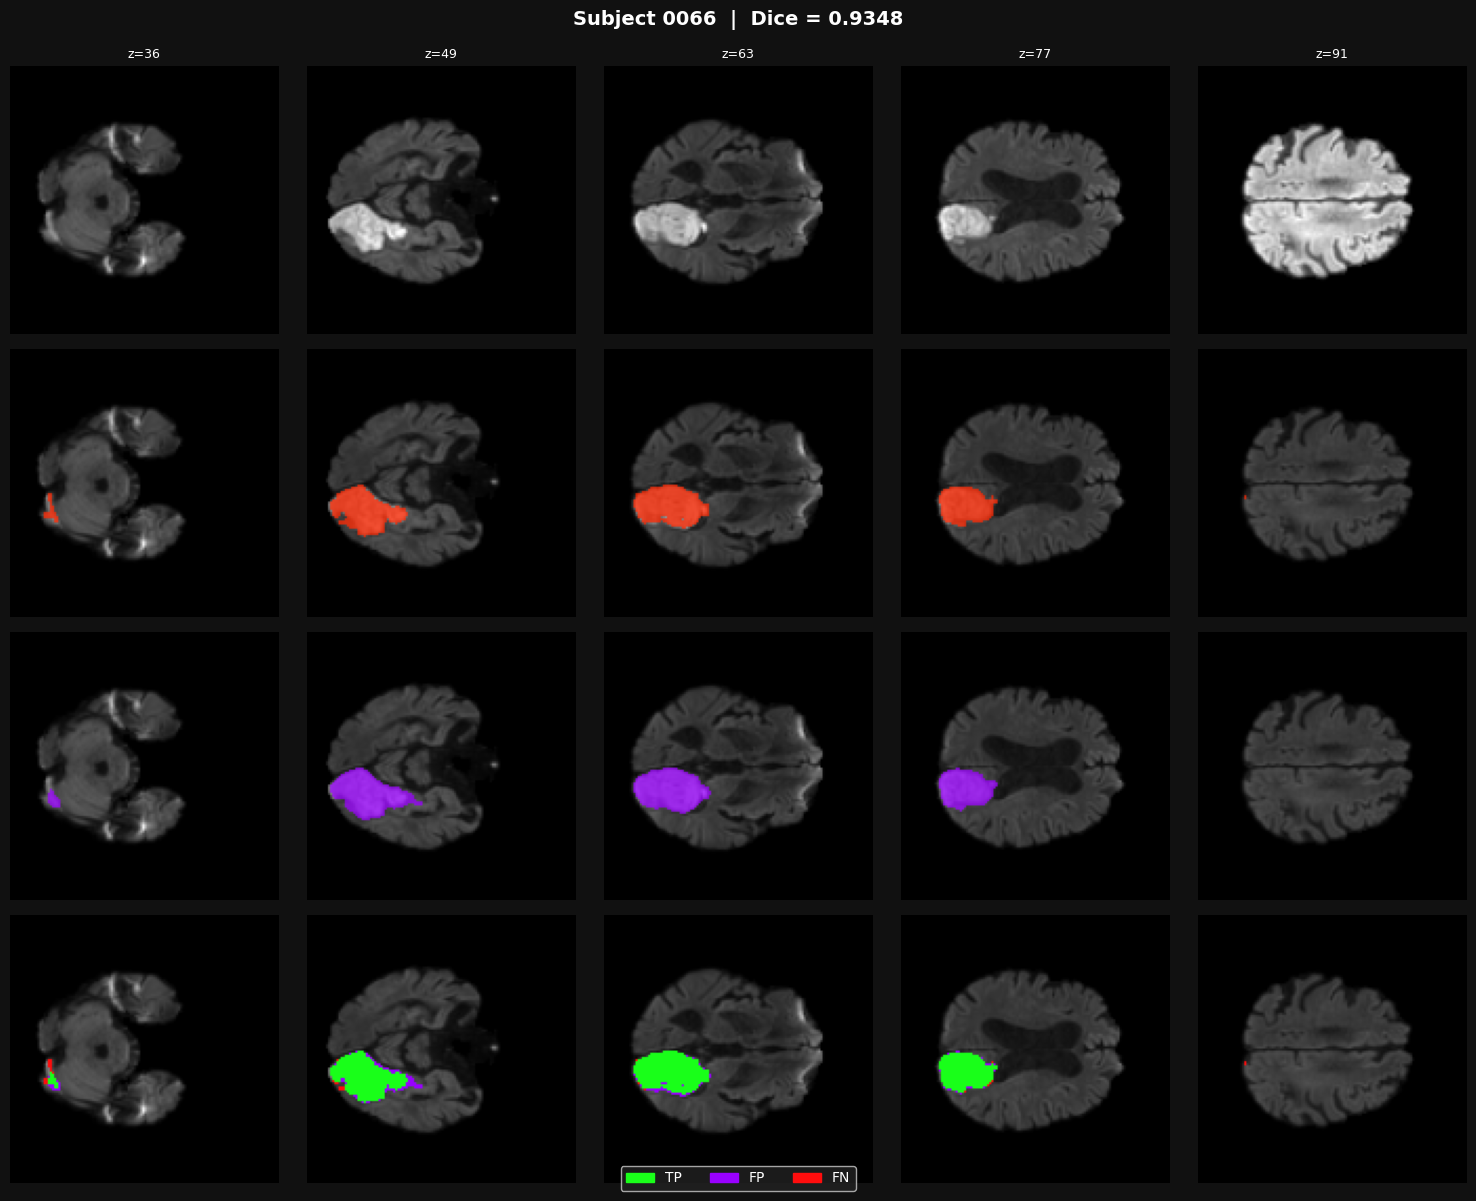

  Saved: /content/drive/MyDrive/MIA/ISLES_RESULTS_MULTIINPUT/visualizations_multiinput/sub-strokecase0066_multiinput_vis.png
Visualizing sub-strokecase0246...
  Dice = 0.8991


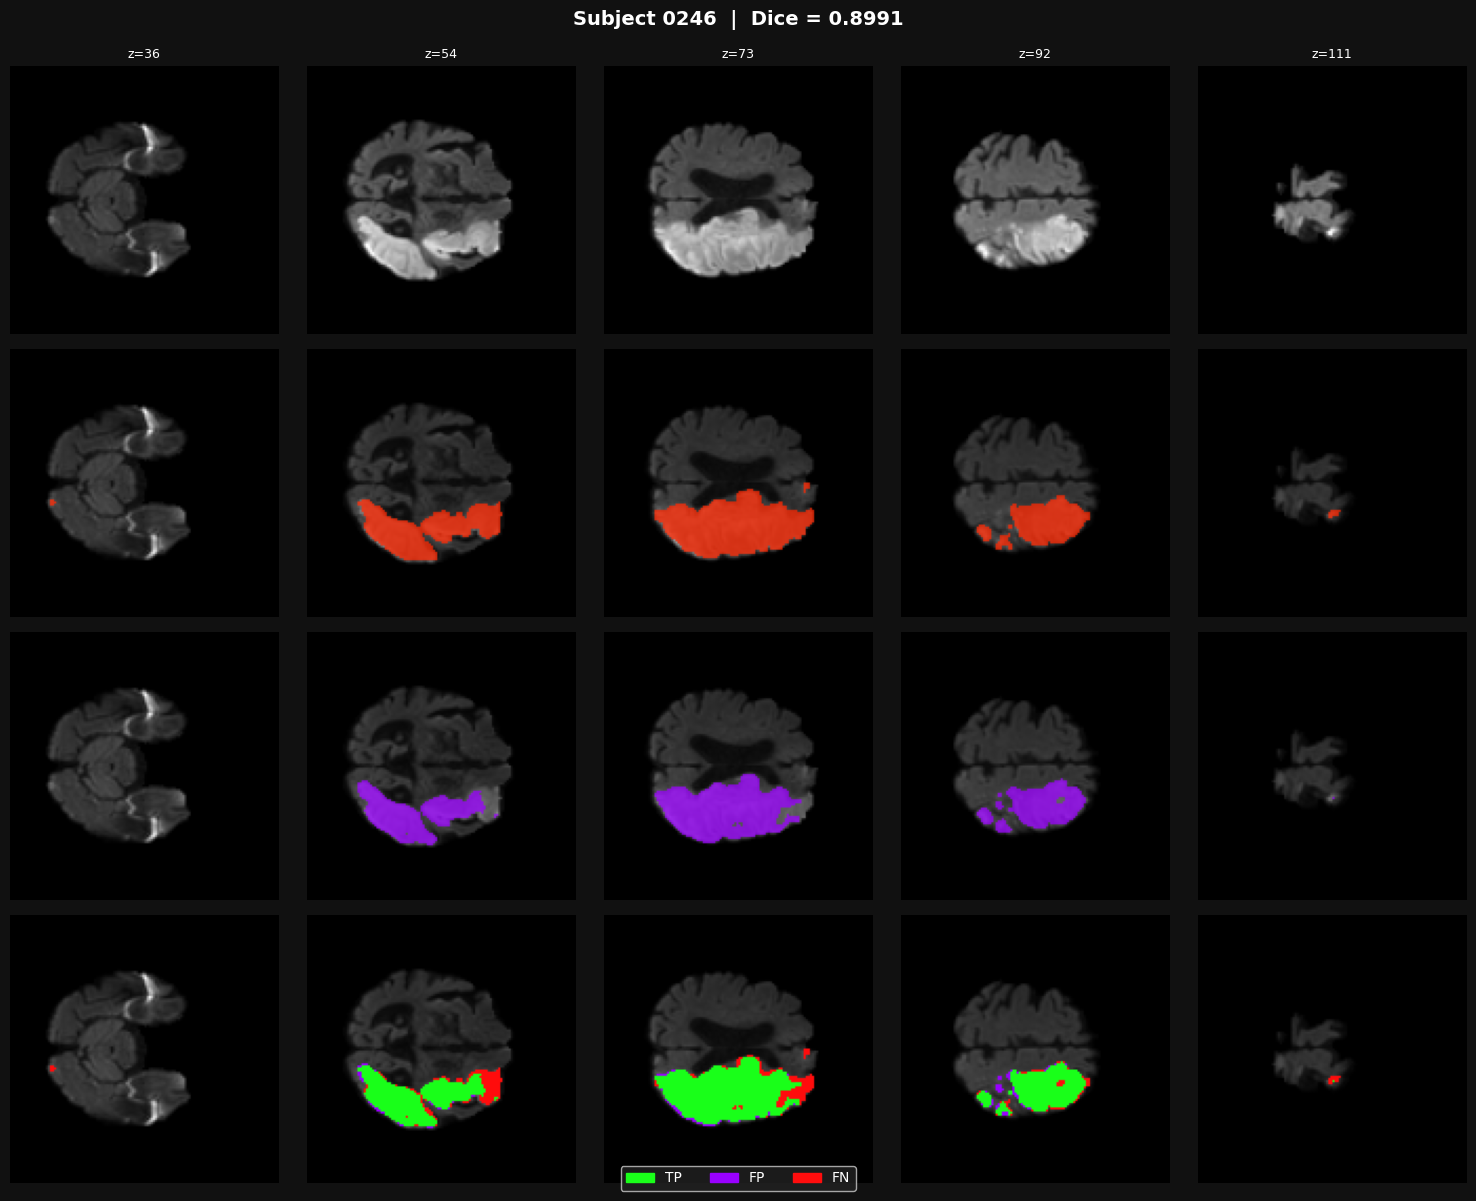

  Saved: /content/drive/MyDrive/MIA/ISLES_RESULTS_MULTIINPUT/visualizations_multiinput/sub-strokecase0246_multiinput_vis.png
Visualizing sub-strokecase0161...
  Dice = 0.9102


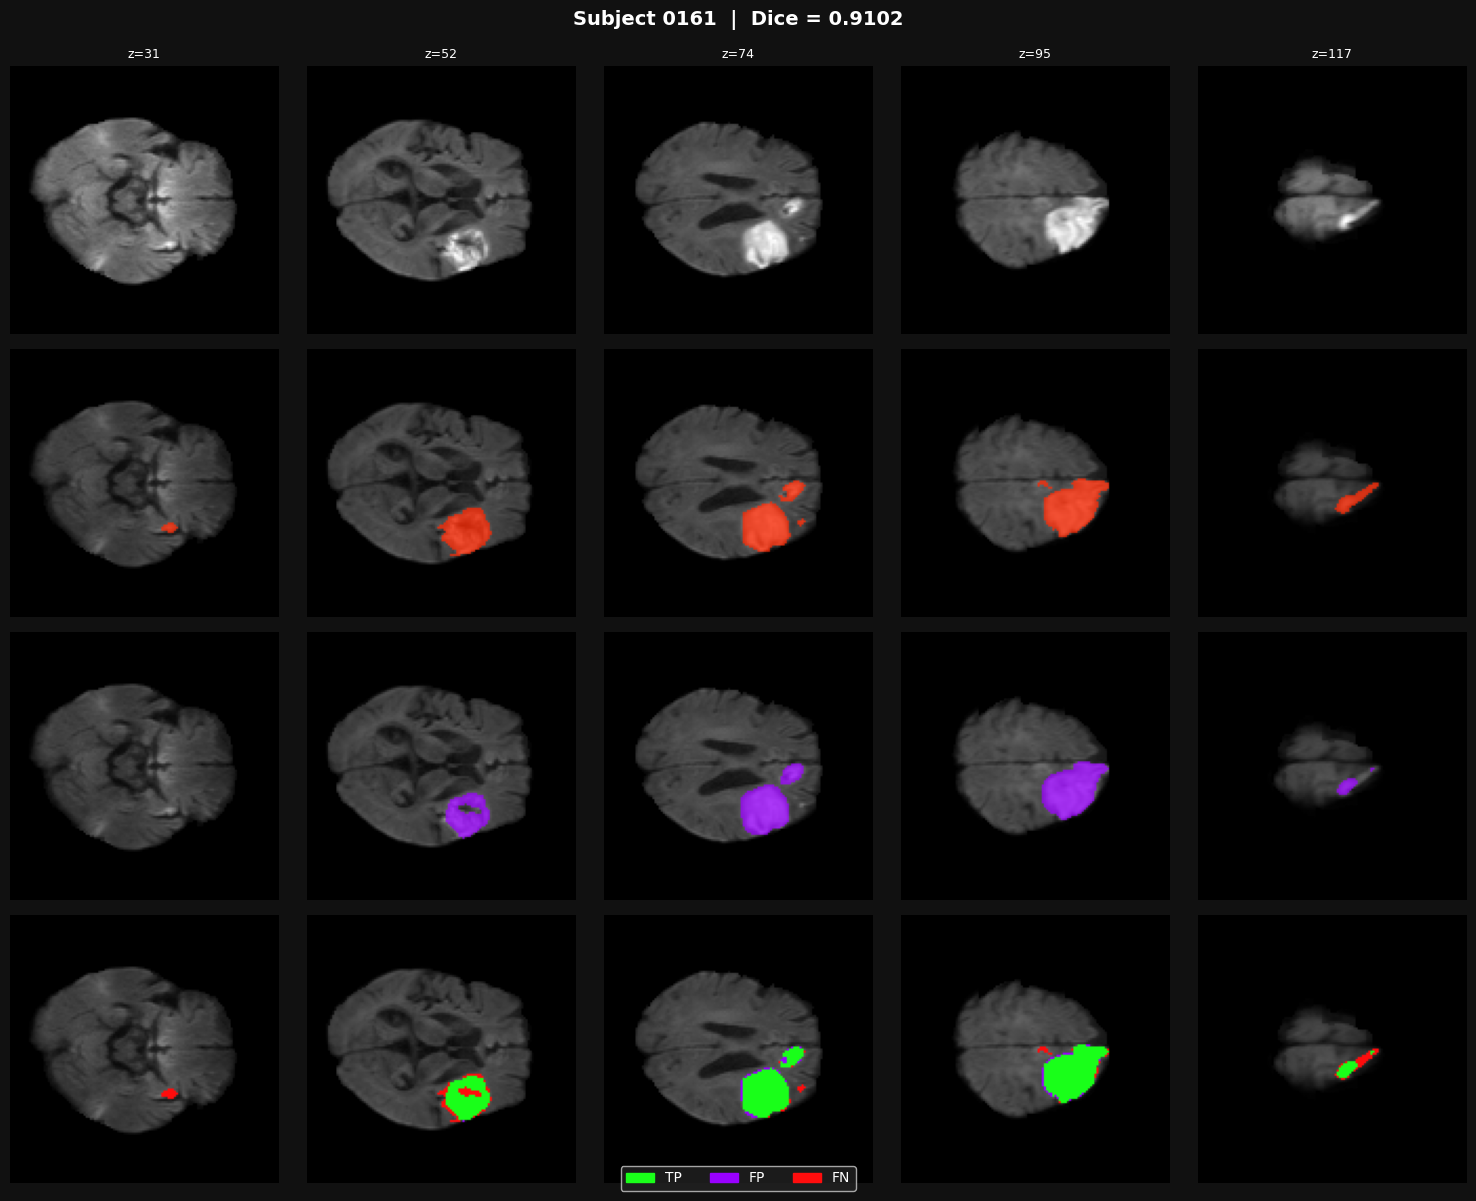

  Saved: /content/drive/MyDrive/MIA/ISLES_RESULTS_MULTIINPUT/visualizations_multiinput/sub-strokecase0161_multiinput_vis.png
Visualizing sub-strokecase0221...
  Dice = 0.8909


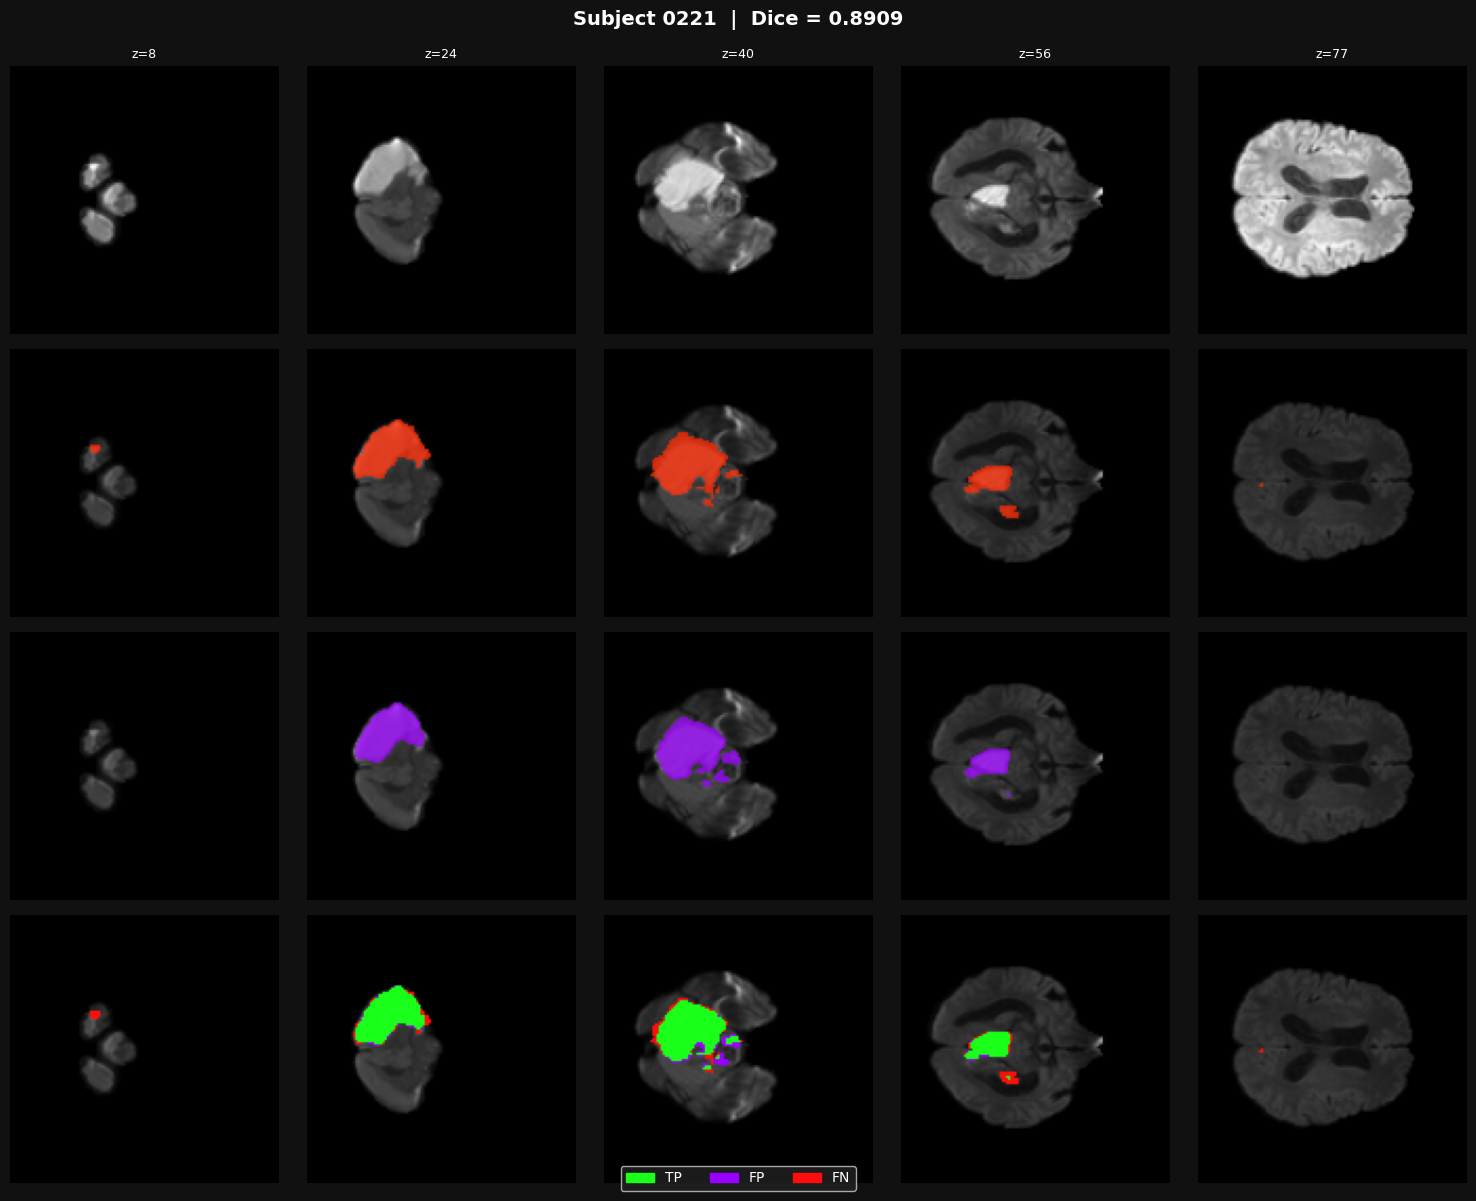

  Saved: /content/drive/MyDrive/MIA/ISLES_RESULTS_MULTIINPUT/visualizations_multiinput/sub-strokecase0221_multiinput_vis.png
Visualizing sub-strokecase0047...
  Dice = 0.9033


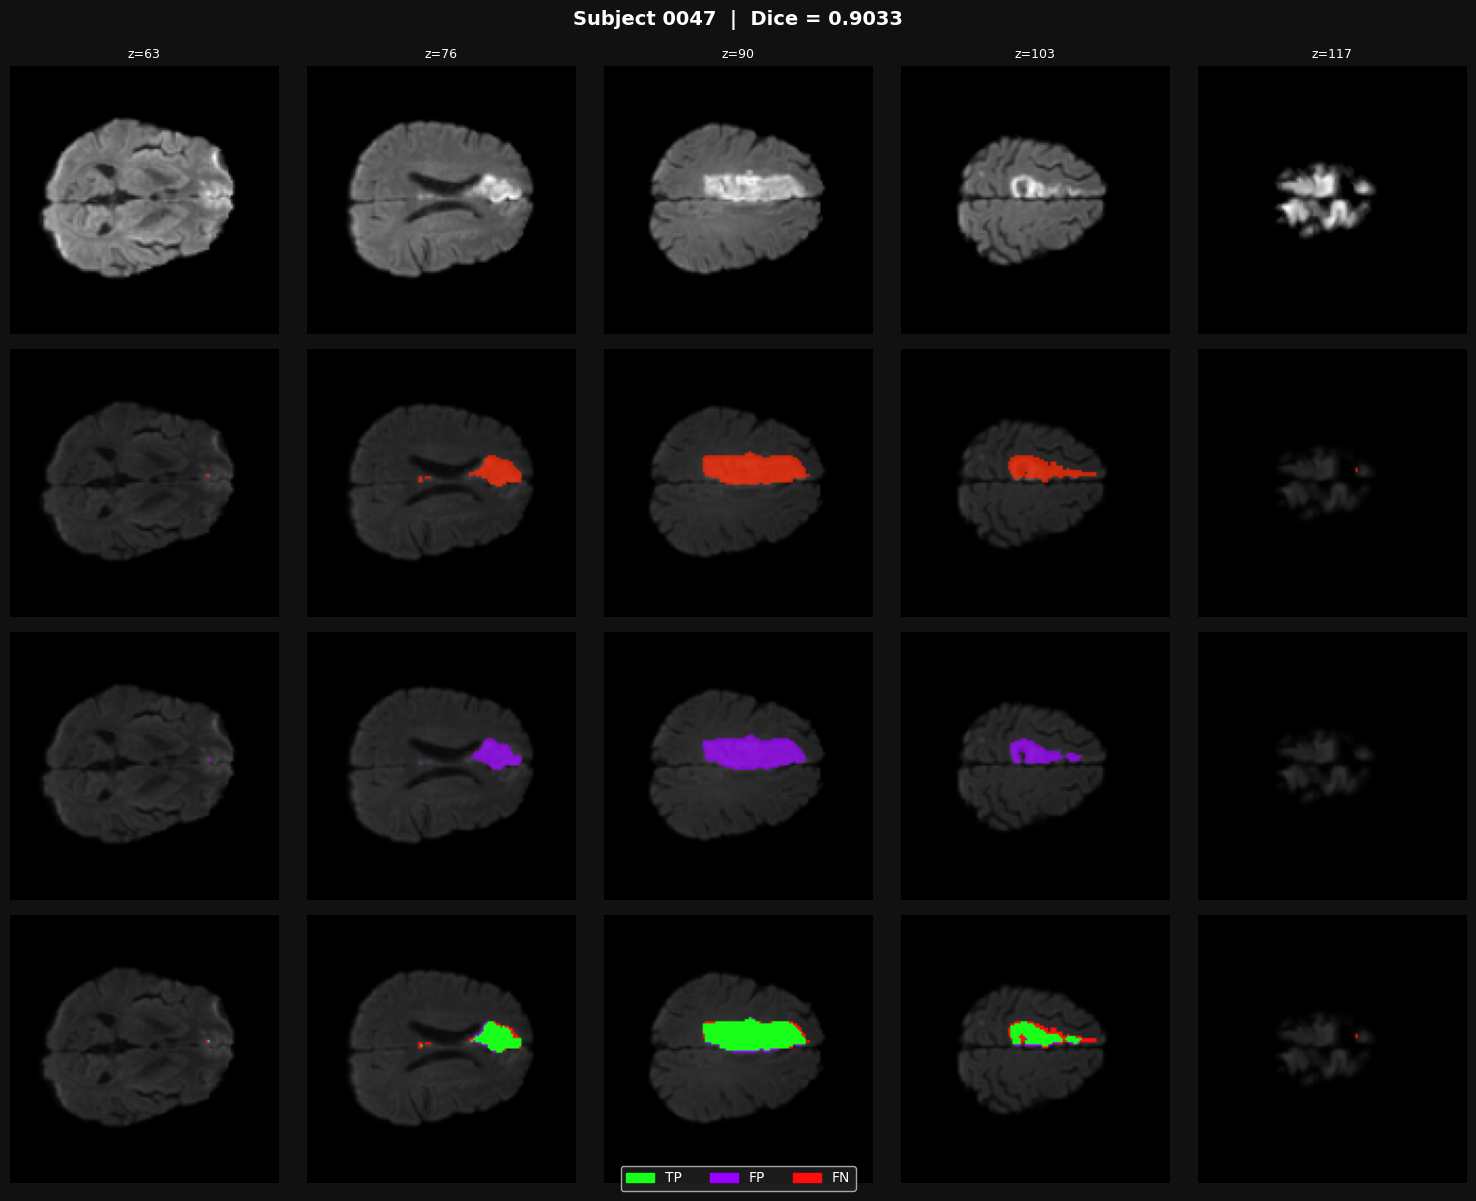

  Saved: /content/drive/MyDrive/MIA/ISLES_RESULTS_MULTIINPUT/visualizations_multiinput/sub-strokecase0047_multiinput_vis.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

THRESHOLD  = 0.5
GT_COLOR   = np.array([1.0, 0.15, 0.0])   # orange-red
PRED_COLOR = np.array([0.6, 0.0,  1.0])   # purple
TP_COLOR   = np.array([0.1, 1.0,  0.1])   # green
FP_COLOR   = np.array([0.6, 0.0,  1.0])   # purple
FN_COLOR   = np.array([1.0, 0.05, 0.05])  # red
ALPHA      = 0.75

def normalize(arr):
    mn, mx = float(arr.min()), float(arr.max())
    return (arr - mn) / (mx - mn + 1e-8)

def visualize_case(cid, models):
    print(f"Visualizing {cid}...")
    # Load image & GT
    img_3ch = load_multiinput_case(cid)        # (3,128,128,128)
    gt      = load_gt(cid)                    # (128,128,128)

    # Run ensemble of 3 folds
    img_batch = img_3ch.unsqueeze(0).to(device)  # (1,3,128,128,128)
    probs = []
    with torch.no_grad():
        for m in models:
            logits = m(img_batch)                  # (1,1,128,128,128)
            probs.append(torch.sigmoid(logits)[0,0].cpu().numpy())
    prob_ens = np.mean(probs, axis=0)             # (128,128,128)
    pred_bin = (prob_ens > THRESHOLD).astype(np.float32)

    # Compute Dice
    tp = ((pred_bin == 1) & (gt == 1)).sum()
    fp = ((pred_bin == 1) & (gt == 0)).sum()
    fn = ((pred_bin == 0) & (gt == 1)).sum()
    dice = 2*tp / (2*tp + fp + fn + 1e-5)
    print(f"  Dice = {dice:.4f}")

    # Use DWI as background
    dwi = img_3ch[0].cpu().numpy()              # (128,128,128)
    dwi = normalize(dwi)

    # Find slices with lesion
    lesion_slices = np.where(gt.sum(axis=(0,1)) > 0)[0]
    if len(lesion_slices) == 0:
        lesion_slices = np.array([gt.shape[2]//2])
    chosen = lesion_slices[np.linspace(
        0, len(lesion_slices)-1, min(5, len(lesion_slices)), dtype=int
    )]

    fig, axes = plt.subplots(4, len(chosen),
                             figsize=(3*len(chosen), 12),
                             facecolor="#111111")

    subject_label = cid.replace("sub-strokecase", "Subject ")
    fig.suptitle(
        f"{subject_label}  |  Dice = {dice:.4f}",
        fontsize=14, fontweight="bold", color="white", y=0.99
    )

    for i, sl in enumerate(chosen):
        dwi_sl = dwi[:, :, sl]
        gt_sl  = gt[:, :, sl]
        pr_sl  = pred_bin[:, :, sl]

        # Row 0: DWI
        axes[0,i].imshow(dwi_sl, cmap="gray", origin="lower")
        axes[0,i].set_title(f"z={sl}", color="white", fontsize=9)
        axes[0,i].axis("off")

        # Row 1: GT
        bg  = np.stack([dwi_sl]*3, axis=-1)
        rgb = bg.copy()
        rgb[gt_sl > 0] = (1-ALPHA)*bg[gt_sl>0] + ALPHA*GT_COLOR
        axes[1,i].imshow(rgb, origin="lower")
        axes[1,i].axis("off")

        # Row 2: Prediction
        bg  = np.stack([dwi_sl]*3, axis=-1)
        rgb = bg.copy()
        rgb[pr_sl > 0] = (1-ALPHA)*bg[pr_sl>0] + ALPHA*PRED_COLOR
        axes[2,i].imshow(rgb, origin="lower")
        axes[2,i].axis("off")

        # Row 3: TP / FP / FN
        bg4  = dwi_sl
        rgb4 = np.stack([bg4, bg4, bg4], axis=-1)
        rgb4[(pr_sl==1) & (gt_sl==1)] = TP_COLOR
        rgb4[(pr_sl==1) & (gt_sl==0)] = FP_COLOR
        rgb4[(pr_sl==0) & (gt_sl==1)] = FN_COLOR
        axes[3,i].imshow(rgb4, origin="lower")
        axes[3,i].axis("off")

    for row, label in enumerate(["DWI", "Ground Truth", "Prediction", "TP / FP / FN"]):
        axes[row,0].set_ylabel(label, color="white", fontsize=11,
                               fontweight="bold", labelpad=10)

    patches = [
        mpatches.Patch(color=TP_COLOR, label="TP"),
        mpatches.Patch(color=FP_COLOR, label="FP"),
        mpatches.Patch(color=FN_COLOR, label="FN"),
    ]
    fig.legend(handles=patches, loc="lower center", ncol=3,
               fontsize=10, facecolor="#222", labelcolor="white",
               bbox_to_anchor=(0.5, 0.0))

    plt.tight_layout()
    save_path = os.path.join(VIS_DIR, f"{cid}_multiinput_vis.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#111111")
    plt.show()
    print("  Saved:", save_path)


# ---- Your chosen subjects ----
subject_ids = [
    "sub-strokecase0066",
    "sub-strokecase0246",
    "sub-strokecase0161",
    "sub-strokecase0221",
    "sub-strokecase0047",
]

for cid in subject_ids:
    visualize_case(cid, models)

In [13]:
def confusion_matrix_3d(gt, pred_bin):
    """gt, pred_bin: numpy arrays of shape (H,W,Z) with values 0/1."""
    gt = gt.astype(bool)
    pred = pred_bin.astype(bool)
    tp = np.logical_and(pred,  gt).sum()
    fp = np.logical_and(pred,  np.logical_not(gt)).sum()
    fn = np.logical_and(np.logical_not(pred), gt).sum()
    tn = np.logical_and(np.logical_not(pred), np.logical_not(gt)).sum()
    return int(tp), int(fp), int(fn), int(tn)

def compute_confusion_for_case(cid, models):
    # Load data
    img_3ch = load_multiinput_case(cid)      # (3,128,128,128) torch
    gt      = load_gt(cid)                  # (128,128,128) numpy, 0/1

    # Ensemble prediction
    img_batch = img_3ch.unsqueeze(0).to(device)  # (1,3,128,128,128)
    probs = []
    with torch.no_grad():
        for m in models:
            logits = m(img_batch)                  # (1,1,128,128,128)
            probs.append(torch.sigmoid(logits)[0,0].cpu().numpy())
    prob_ens = np.mean(probs, axis=0)             # (128,128,128)
    pred_bin = (prob_ens > THRESHOLD).astype(np.float32)

    tp, fp, fn, tn = confusion_matrix_3d(gt, pred_bin)

    dice = 2*tp / (2*tp + fp + fn + 1e-5)
    precision = tp / (tp + fp + 1e-5)
    recall    = tp / (tp + fn + 1e-5)

    return {
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "dice": float(dice),
        "precision": float(precision),
        "recall": float(recall)
    }

# ---- subjects you care about ----
subject_ids = [
    "sub-strokecase0066",
    "sub-strokecase0246",
    "sub-strokecase0161",
    "sub-strokecase0221",
    "sub-strokecase0047",
]

print("Voxel-wise confusion matrix per subject:\n")
for cid in subject_ids:
    stats = compute_confusion_for_case(cid, models)
    subj = cid.replace("sub-strokecase", "Subject ")
    print(f"{subj}")
    print(f"  TP: {stats['tp']}")
    print(f"  FP: {stats['fp']}")
    print(f"  FN: {stats['fn']}")
    print(f"  TN: {stats['tn']}")
    print(f"  Dice:      {stats['dice']:.4f}")
    print(f"  Precision: {stats['precision']:.4f}")
    print(f"  Recall:    {stats['recall']:.4f}")
    print("-"*40)

Voxel-wise confusion matrix per subject:

Subject 0066
  TP: 20004
  FP: 2341
  FN: 450
  TN: 2074357
  Dice:      0.9348
  Precision: 0.8952
  Recall:    0.9780
----------------------------------------
Subject 0246
  TP: 53475
  FP: 2761
  FN: 9235
  TN: 2031681
  Dice:      0.8991
  Precision: 0.9509
  Recall:    0.8527
----------------------------------------
Subject 0161
  TP: 28440
  FP: 2688
  FN: 2923
  TN: 2063101
  Dice:      0.9102
  Precision: 0.9136
  Recall:    0.9068
----------------------------------------
Subject 0221
  TP: 22886
  FP: 1502
  FN: 4104
  TN: 2068660
  Dice:      0.8909
  Precision: 0.9384
  Recall:    0.8479
----------------------------------------
Subject 0047
  TP: 13040
  FP: 729
  FN: 2063
  TN: 2081320
  Dice:      0.9033
  Precision: 0.9471
  Recall:    0.8634
----------------------------------------


In [15]:
import numpy as np
import matplotlib.pyplot as plt

def confusion_matrix_3d(gt, pred_bin):
    gt   = gt.astype(bool)
    pred = pred_bin.astype(bool)
    tp = np.logical_and(pred,  gt).sum()
    fp = np.logical_and(pred,  ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    tn = np.logical_and(~pred, ~gt).sum()
    return int(tp), int(fp), int(fn), int(tn)

def ensemble_predict_volume(cid, models):
    img_3ch = load_multiinput_case(cid)          # (3,128,128,128) torch
    img_b   = img_3ch.unsqueeze(0).to(device)    # (1,3,128,128,128)
    probs = []
    with torch.no_grad():
        for m in models:
            logits = m(img_b)                    # (1,1,128,128,128)
            probs.append(torch.sigmoid(logits)[0,0].cpu().numpy())
    prob_ens = np.mean(probs, axis=0)            # (128,128,128)
    return prob_ens

# ---- only these 5 subjects ----
subject_ids = [
    "sub-strokecase0066",
    "sub-strokecase0246",
    "sub-strokecase0161",
    "sub-strokecase0221",
    "sub-strokecase0047",
]

total_tp = total_fp = total_fn = total_tn = 0

print("Per-subject metrics (5 subjects):\n")
for cid in subject_ids:
    try:
        gt = load_gt(cid)                              # (128,128,128)
        prob_ens = ensemble_predict_volume(cid, models)
        pred_bin = (prob_ens > THRESHOLD).astype(np.float32)

        tp, fp, fn, tn = confusion_matrix_3d(gt, pred_bin)

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_tn += tn

        dice = 2*tp / (2*tp + fp + fn + 1e-5)
        prec = tp / (tp + fp + 1e-5)
        rec  = tp / (tp + fn + 1e-5)

        print(f"{cid.replace('sub-strokecase','Subject ')}")
        print(f"  TP={tp}, FP={fp}, FN={fn}, TN={tn}")
        print(f"  Dice={dice:.4f}, Precision={prec:.4f}, Recall={rec:.4f}")
        print("-"*40)

    except Exception as e:
        print(f"Skipping {cid}: {e}")

print("\nCombined over 5 subjects:")
print(f"  TP: {total_tp}")
print(f"  FP: {total_fp}")
print(f"  FN: {total_fn}")
print(f"  TN: {total_tn}")

overall_dice = 2*total_tp / (2*total_tp + total_fp + total_fn + 1e-5)
overall_prec = total_tp / (total_tp + total_fp + 1e-5)
overall_rec  = total_tp / (total_tp + total_fn + 1e-5)
print(f"  Dice={overall_dice:.4f}, Precision={overall_prec:.4f}, Recall={overall_rec:.4f}")

Per-subject metrics (5 subjects):

Subject 0066
  TP=20004, FP=2341, FN=450, TN=2074357
  Dice=0.9348, Precision=0.8952, Recall=0.9780
----------------------------------------
Subject 0246
  TP=53475, FP=2761, FN=9235, TN=2031681
  Dice=0.8991, Precision=0.9509, Recall=0.8527
----------------------------------------
Subject 0161
  TP=28440, FP=2688, FN=2923, TN=2063101
  Dice=0.9102, Precision=0.9136, Recall=0.9068
----------------------------------------
Subject 0221
  TP=22886, FP=1502, FN=4104, TN=2068660
  Dice=0.8909, Precision=0.9384, Recall=0.8479
----------------------------------------
Subject 0047
  TP=13040, FP=729, FN=2063, TN=2081320
  Dice=0.9033, Precision=0.9471, Recall=0.8634
----------------------------------------

Combined over 5 subjects:
  TP: 137845
  FP: 10021
  FN: 18775
  TN: 10319119
  Dice=0.9054, Precision=0.9322, Recall=0.8801


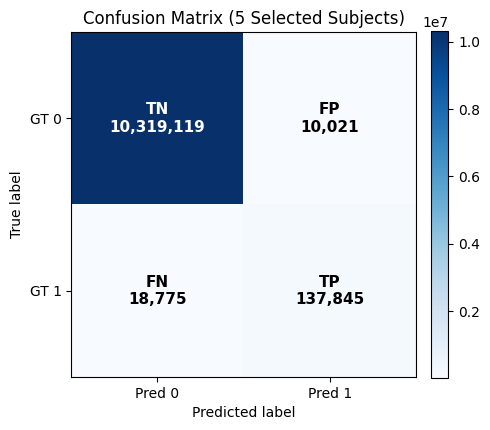

Saved confusion matrix to: /content/drive/MyDrive/MIA/ISLES_RESULTS_MULTIINPUT/visualizations_multiinput/confusion_matrix_5subjects.png


In [16]:
# Build 2x2 confusion matrix for the 5 subjects
cm = np.array([
    [total_tn, total_fp],
    [total_fn, total_tp]
], dtype=np.int64)

labels = [["TN", "FP"],
          ["FN", "TP"]]

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap="Blues")

for i in range(2):
    for j in range(2):
        ax.text(j, i,
                f"{labels[i][j]}\n{cm[i,j]:,}",
                ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black",
                fontsize=11, fontweight="bold")

ax.set_xticks([0,1])
ax.set_xticklabels(["Pred 0", "Pred 1"])
ax.set_yticks([0,1])
ax.set_yticklabels(["GT 0", "GT 1"])
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix (5 Selected Subjects)")

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()

cm_path = os.path.join(VIS_DIR, "confusion_matrix_5subjects.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved confusion matrix to:", cm_path)

Total unique val cases: 150
sub-strokecase0001: Dice = 0.4930
sub-strokecase0003: Dice = 0.8656
sub-strokecase0005: Dice = 0.6592
sub-strokecase0006: Dice = 0.0000
sub-strokecase0007: Dice = 0.0068
sub-strokecase0010: Dice = 0.5530
sub-strokecase0011: Dice = 0.6581
sub-strokecase0012: Dice = 0.4407
sub-strokecase0013: Dice = 0.7442
sub-strokecase0016: Dice = 0.0000
sub-strokecase0017: Dice = 0.7432
sub-strokecase0019: Dice = 0.7926
sub-strokecase0020: Dice = 0.8689
sub-strokecase0023: Dice = 0.4018
sub-strokecase0025: Dice = 0.5526
sub-strokecase0026: Dice = 0.5467
sub-strokecase0027: Dice = 0.2030
sub-strokecase0028: Dice = 0.7339
sub-strokecase0029: Dice = 0.7498
sub-strokecase0030: Dice = 0.0000
sub-strokecase0031: Dice = 0.8341
sub-strokecase0032: Dice = 0.6963
sub-strokecase0033: Dice = 0.7220
sub-strokecase0034: Dice = 0.6643
sub-strokecase0036: Dice = 0.7084
sub-strokecase0037: Dice = 0.0000
sub-strokecase0039: Dice = 0.8380
sub-strokecase0042: Dice = 0.8068
sub-strokecase0043: 

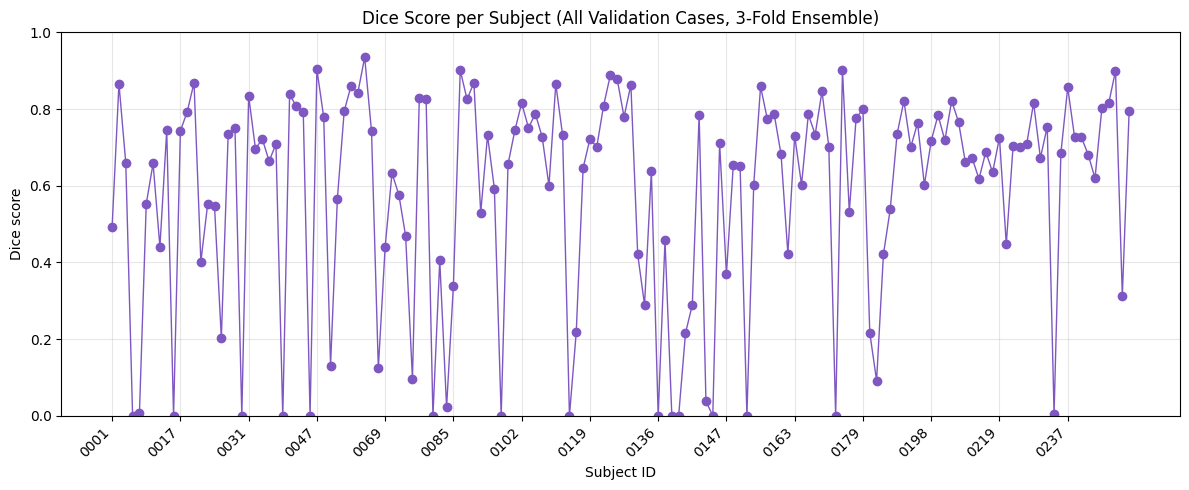

Saved: /content/drive/MyDrive/MIA/ISLES_RESULTS_MULTIINPUT/visualizations_multiinput/dice_per_subject_val.png


In [19]:
import matplotlib.pyplot as plt
import numpy as np

def ensemble_predict_volume(cid, models):
    img_3ch = load_multiinput_case(cid)          # (3,128,128,128) torch
    img_b   = img_3ch.unsqueeze(0).to(device)    # (1,3,128,128,128)
    probs = []
    with torch.no_grad():
        for m in models:
            logits = m(img_b)                    # (1,1,128,128,128)
            probs.append(torch.sigmoid(logits)[0,0].cpu().numpy())
    prob_ens = np.mean(probs, axis=0)            # (128,128,128)
    return prob_ens

def dice_from_prob(gt, prob, thr=0.5):
    pred_bin = (prob > thr).astype(np.float32)
    tp = ((pred_bin==1) & (gt==1)).sum()
    fp = ((pred_bin==1) & (gt==0)).sum()
    fn = ((pred_bin==0) & (gt==1)).sum()
    return 2*tp / (2*tp + fp + fn + 1e-5)

# Get unique validation cases across folds 1–3
val_cases_all = set()
for fold in range(3):
    _, val_idx = splits[fold]
    for cid in all_cases[val_idx]:
        val_cases_all.add(cid)
val_cases_all = sorted(list(val_cases_all))
print(f"Total unique val cases: {len(val_cases_all)}")

dice_per_case = {}

for cid in val_cases_all:
    try:
        gt = load_gt(cid)                       # (128,128,128) numpy
        prob_ens = ensemble_predict_volume(cid, models)
        d = dice_from_prob(gt, prob_ens, THRESHOLD)
        dice_per_case[cid] = float(d)
        print(f"{cid}: Dice = {d:.4f}")
    except Exception as e:
        print(f"Skipping {cid}: {e}")

# Plot graph
case_ids = sorted(dice_per_case.keys())
dice_vals = [dice_per_case[c] for c in case_ids]

x = np.arange(len(case_ids))
x_labels = [c.replace("sub-strokecase", "") for c in case_ids]

plt.figure(figsize=(12, 5))
plt.plot(x, dice_vals, marker="o", linestyle="-", color="#7E57C2", linewidth=1)

plt.xticks(x[::10], x_labels[::10], rotation=45, ha="right")  # label every 10th case
plt.ylim(0, 1.0)
plt.xlabel("Subject ID")
plt.ylabel("Dice score")
plt.title("Dice Score per Subject (All Validation Cases, 3-Fold Ensemble)")
plt.grid(alpha=0.3)

plt.tight_layout()
save_path = os.path.join(VIS_DIR, "dice_per_subject_val.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", save_path)